# Finetune Jina v5 Embeddings for Arabic Dictionary Retrieval

Finetunes `jina-embeddings-v5-text-nano-retrieval` (239M params) on curated Arabic WordNet
triplets to improve definition-based dictionary retrieval.

**Goal:** Improve `definition_keyword` Recall@10 from ~48% to ~80%+

| | Train | Eval |
|---|---|---|
| **Triplets** (anchor, positive, negative) | 4,660 | 1,512 |
| **Synsets** (no leakage) | 105 | 32 |
| **Positive sources** | 74% original + 26% step05 | — |
| **Negative sources** | 96% soft + 4% hard | — |

**Hardware:** T4 GPU (16GB VRAM) — Colab free tier

**Approach:** `MultipleNegativesRankingLoss` wrapped in `MatryoshkaLoss`, using the
pre-merged retrieval checkpoint (no dynamic LoRA routing needed).

## 1. Setup

In [3]:
# Verify GPU availability and VRAM
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Tesla T4, 15360 MiB, 14910 MiB
CUDA: True
Device: Tesla T4
VRAM: 15.6 GB


In [5]:
!pip install -q condacolab
import condacolab
condacolab.install()  # this restarts the runtime automatically

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [1]:
!conda install -c conda-forge faiss-gpu -y


Channels:
 - conda-forge
Platform: linux-64
Solving environment: / - \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - faiss-gpu


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    cudatoolkit-11.8.0         |      h4ba93d1_13       682.5 MB  conda-forge
    faiss-1.9.0                |py311cuda118haa09c8f_0_cuda         1.5 MB  conda-forge
    faiss-gpu-1.9.0            |       h418687c_0          18 KB  conda-forge
    kernel-headers_linux-64-5.14.0|       he073ed8_3         1.3 MB  conda-forge
    libblas-3.9.0              |31_h59b9bed_openblas          16 KB  conda-forge
    libcblas-3.9.0        

In [2]:
# Install dependencies
!pip install -q -U "sentence-transformers[train]" datasets transformers peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.6/806.6 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.2/800.2 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.5/915.5 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Upload and extract finetuning data
import zipfile, os, json
import shutil

drive_file_path = "/content/drive/MyDrive/Colab Notebooks/data/jina_finetune_colab/jina_finetune_data.zip"
local_zip_path = "jina_finetune_data.zip"

print(f"Copying {drive_file_path} to {local_zip_path}...")
shutil.copyfile(drive_file_path, local_zip_path)

with zipfile.ZipFile(local_zip_path, "r") as z:
    z.extractall(".")

# Verify contents
data_dir = "jina_finetune_data"
for f in sorted(os.listdir(data_dir)):
    size = os.path.getsize(os.path.join(data_dir, f))
    print(f"  {f:30s} {size/1024:.0f} KB")

stats = json.load(open(os.path.join(data_dir, "stats.json")))
print(f"\nTrain triplets: {stats['train_triplets']:,}")
print(f"Eval triplets:  {stats['eval_triplets']:,}")
print(f"Synsets:        {stats['synsets_processed']}")

Copying /content/drive/MyDrive/Colab Notebooks/data/jina_finetune_colab/jina_finetune_data.zip to jina_finetune_data.zip...
  pairs_eval.jsonl               173 KB
  pairs_train.jsonl              698 KB
  stats.json                     1 KB
  triplets_eval.jsonl            7504 KB
  triplets_train.jsonl           23185 KB

Train triplets: 4,660
Eval triplets:  1,512
Synsets:        137


## 2. Load & Explore Data

In [2]:
import json
from datasets import Dataset

def load_triplets(path):
    """Load JSONL triplets, keeping only anchor/positive/negative."""
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            rows.append({
                "anchor": obj["anchor"],
                "positive": obj["positive"],
                "negative": obj["negative"],
            })
    return Dataset.from_list(rows)

train_dataset = load_triplets(f"{data_dir}/triplets_train.jsonl")
eval_dataset = load_triplets(f"{data_dir}/triplets_eval.jsonl")

print(f"Train: {len(train_dataset):,} triplets")
print(f"Eval:  {len(eval_dataset):,} triplets")
print(f"\nColumns: {train_dataset.column_names}")

# Length distribution
import numpy as np
for field in ["anchor", "positive", "negative"]:
    lengths = [len(x) for x in train_dataset[field]]
    print(f"\n{field}: median={np.median(lengths):.0f} chars, "
          f"mean={np.mean(lengths):.0f}, p90={np.percentile(lengths, 90):.0f}, "
          f"max={max(lengths)}")

Train: 4,660 triplets
Eval:  1,512 triplets

Columns: ['anchor', 'positive', 'negative']

anchor: median=68 chars, mean=74, p90=105, max=166

positive: median=648 chars, mean=1776, p90=4603, max=25385

negative: median=173 chars, mean=842, p90=1020, max=42763


In [3]:
# Spot-check: display first example
ex = train_dataset[0]
print("=" * 60)
print("ANCHOR (query):")
print(ex["anchor"][:200])
print("\nPOSITIVE (relevant doc):")
print(ex["positive"][:400])
print("\nNEGATIVE (irrelevant doc):")
print(ex["negative"][:400])
print("=" * 60)

ANCHOR (query):
Query: كَيْنُونَة كِيَان — ما يُدرَك أو يُعرَف أو يُستدَلّ على وجوده المستقل، سواء أكان حيًّا أم غير حيّ

POSITIVE (relevant doc):
Document: # كيان (جذر: كن)

## Data and AI Glossary
*معجم البيانات والذكاء الاصطناعي (2024)*
EN: Entity

شيء مادي أو غير مادي يمكن التعرُّف عليه وتمييزه بوضوح.

## Dictionary of Information Technology Terms
*معجم مصطلحات المعلوماتية (2000)*
EN: entity

في التصميم بمعونة الحاسوب والتصميم الغرضي التوجه: بندٌ يمكِن أن يعامَلَ كوحدة مستقلة، وغالباً كعضو من نوع أو صنف معيَّن.

## Education
*مسرد التربي

NEGATIVE (irrelevant doc):
Document: # (1) كينونة؛ وجود
(2) الكائنات مجتمعةً
(3) كائن
(4) حياة؛ بقاء struggle for existence
(5) أسلوبُ حياةٍ.


## Al-Mawrid Al-Hadeeth
*المورد الحديث (2008)*
EN: existence

(1) كينونة؛ وجود
(2) الكائنات مجتمعةً
(3) كائن
(4) حياة؛ بقاء struggle for existence
(5) أسلوبُ حياةٍ.



## 3. Baseline Evaluation

Build an `InformationRetrievalEvaluator` from the eval split to measure Recall@10,
NDCG@10, and MRR before and after finetuning.

We construct:
- **queries**: unique anchors from eval triplets
- **corpus**: all unique positive + negative documents
- **relevant_docs**: mapping each query to its positive document IDs

In [4]:
from sentence_transformers.evaluation import InformationRetrievalEvaluator
import hashlib

def doc_id(text):
    """Stable short ID from document text."""
    return hashlib.md5(text.encode("utf-8")).hexdigest()[:12]

def build_evaluator(dataset, name="eval"):
    """Build IR evaluator from triplet dataset."""
    queries = {}      # qid -> query text
    corpus = {}       # did -> document text
    relevant = {}     # qid -> set of relevant dids

    for row in dataset:
        anchor = row["anchor"]
        positive = row["positive"]
        negative = row["negative"]

        qid = doc_id(anchor)
        pid = doc_id(positive)
        nid = doc_id(negative)

        queries[qid] = anchor
        corpus[pid] = positive
        corpus[nid] = negative

        if qid not in relevant:
            relevant[qid] = set()
        relevant[qid].add(pid)

    print(f"Evaluator '{name}': {len(queries)} queries, {len(corpus)} docs, "
          f"{sum(len(v) for v in relevant.values())} relevance judgments")

    return InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant,
        name=name,
        show_progress_bar=True,
    )

evaluator = build_evaluator(eval_dataset, name="jina-v5-nano-eval")
print("Evaluator ready.")

Evaluator 'jina-v5-nano-eval': 28 queries, 861 docs, 50 relevance judgments
Evaluator ready.


In [5]:
import torch
from sentence_transformers import SentenceTransformer

MODEL_ID = "jinaai/jina-embeddings-v5-text-nano-retrieval"

model = SentenceTransformer(
    MODEL_ID,
    trust_remote_code=True,
    model_kwargs={"dtype": torch.bfloat16},
)
model.max_seq_length = 512

print(f"Model: {MODEL_ID}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"max_seq_length: {model.max_seq_length}")
print(f"Embedding dim: {model.get_sentence_embedding_dimension()}")

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}


Loading weights:   0%|          | 0/110 [00:00<?, ?it/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}


Model: jinaai/jina-embeddings-v5-text-nano-retrieval
Parameters: 211,766,016
max_seq_length: 512
Embedding dim: 768


In [6]:
# Run baseline evaluation (before finetuning)
print("Running baseline evaluation...")
baseline_metrics = evaluator(model)

# Extract key metrics
baseline_keys = {
    "NDCG@10":   "cosine_ndcg@10",
    "Recall@10":  "cosine_recall@10",
    "Recall@25":  "cosine_recall@25",
    "MRR@10":     "cosine_mrr@10",
    "MAP@100":    "cosine_map@100",
}

eval_name = "jina-v5-nano-eval"
print("\n" + "=" * 40)
print("BASELINE (pre-finetune)")
print("=" * 40)
baseline_results = {}
for label, key in baseline_keys.items():
    full_key = f"{eval_name}_{key}"
    val = baseline_metrics.get(full_key, 0)
    baseline_results[label] = val
    print(f"  {label:12s} {val:.4f}")

Running baseline evaluation...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:15<00:00, 15.41s/it]


BASELINE (pre-finetune)
  NDCG@10      0.5021
  Recall@10    0.7155
  Recall@25    0.0000
  MRR@10       0.5054
  MAP@100      0.4054


## 4. Loss Function

**MultipleNegativesRankingLoss (MNRL)** wrapped in **MatryoshkaLoss**.

MNRL with triplet data uses explicit hard negatives AND in-batch negatives:
- Each row provides 1 hard negative (the `negative` column)
- All other positives in the batch serve as additional in-batch negatives
- With `batch_size=32`: 1 hard + 31 in-batch = 32 total negatives per query

MatryoshkaLoss preserves performance at truncated embedding dimensions
(768 → 512 → ... → 32), matching how the original model was trained.

In [7]:
from sentence_transformers.losses import MultipleNegativesRankingLoss, MatryoshkaLoss

inner_loss = MultipleNegativesRankingLoss(model)

# v5-nano Matryoshka dimensions (max dim = 768)
matryoshka_dims = [768, 512, 256, 128, 64, 32]

loss = MatryoshkaLoss(
    model=model,
    loss=inner_loss,
    matryoshka_dims=matryoshka_dims,
    matryoshka_weights=[1.0] * len(matryoshka_dims),
)

print(f"Loss: MatryoshkaLoss(MNRL)")
print(f"Matryoshka dims: {matryoshka_dims}")

Loss: MatryoshkaLoss(MNRL)
Matryoshka dims: [768, 512, 256, 128, 64, 32]


In [8]:
# Login to Weights & Biases and HuggingFace Hub
!pip install -q wandb
import wandb
wandb.login()

from huggingface_hub import notebook_login
notebook_login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sabdo (sabdo-stevens-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 5. Training

**Key hyperparameters:**
- `lr=2e-5` — ~100x smaller than pre-training, prevents catastrophic forgetting
- `epochs=5` — small dataset (4,660 triplets), guide recommends 3-10 for 1K-5K
- `batch_size=32` — gives 32 negatives per query via MNRL; fits in T4 16GB at seq_len=512
- `NO_DUPLICATES` batch sampler — prevents sampling the same passage twice in a batch
- `load_best_model_at_end` — picks the checkpoint with best eval NDCG@10

In [16]:
from sentence_transformers import (
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.training_args import BatchSamplers

OUTPUT_DIR = "./jina-v5-nano-finetuned"

args = SentenceTransformerTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    warmup_steps=582, # Calculated from warmup_ratio=0.1 * Total steps (~5825)
    lr_scheduler_type="cosine",
    bf16=True,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    logging_steps=10,
    report_to="wandb",
    run_name="jina-v5-nano-arabic-dict",
    push_to_hub=True,
    hub_model_id="SalahAbdoNLP/jina-v5-nano-arabic-dict",
    hub_strategy="every_save",
)

print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {args.num_train_epochs}")
print(f"Batch size: {args.per_device_train_batch_size}")
print(f"Steps/epoch: ~{len(train_dataset) // args.per_device_train_batch_size}")
print(f"Total steps: ~{len(train_dataset) // args.per_device_train_batch_size * int(args.num_train_epochs)}")

Output: ./jina-v5-nano-finetuned
Epochs: 5
Batch size: 8
Steps/epoch: ~582
Total steps: ~2910


In [17]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")


Free VRAM: 13.2 GB


In [ ]:
print()

In [18]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=loss,
    evaluator=evaluator,
)

print("Starting training...")
trainer.train()
print("\nTraining complete!")

Starting training...


Epoch,Training Loss,Validation Loss,Jina-v5-nano-eval Cosine Accuracy@1,Jina-v5-nano-eval Cosine Accuracy@3,Jina-v5-nano-eval Cosine Accuracy@5,Jina-v5-nano-eval Cosine Accuracy@10,Jina-v5-nano-eval Cosine Precision@1,Jina-v5-nano-eval Cosine Precision@3,Jina-v5-nano-eval Cosine Precision@5,Jina-v5-nano-eval Cosine Precision@10,Jina-v5-nano-eval Cosine Recall@1,Jina-v5-nano-eval Cosine Recall@3,Jina-v5-nano-eval Cosine Recall@5,Jina-v5-nano-eval Cosine Recall@10,Jina-v5-nano-eval Cosine Ndcg@10,Jina-v5-nano-eval Cosine Mrr@10,Jina-v5-nano-eval Cosine Map@100
1,3.591722,3.387938,0.321429,0.714286,0.821429,0.892857,0.321429,0.273810,0.228571,0.135714,0.184524,0.483333,0.655952,0.786905,0.557172,0.550397,0.458694
2,0.324057,2.857231,0.392857,0.750000,0.821429,0.928571,0.392857,0.297619,0.250000,0.150000,0.261905,0.525000,0.698810,0.865476,0.622747,0.590023,0.518822
3,0.072937,4.829158,0.571429,0.750000,0.821429,0.857143,0.571429,0.309524,0.235714,0.128571,0.376190,0.560714,0.667857,0.739286,0.631301,0.670635,0.574465
4,0.001077,5.563390,0.535714,0.714286,0.750000,0.821429,0.535714,0.321429,0.228571,0.128571,0.340476,0.550000,0.651190,0.734524,0.608376,0.629308,0.551498
5,0.129630,6.405789,0.535714,0.714286,0.714286,0.821429,0.535714,0.345238,0.214286,0.135714,0.358333,0.590476,0.597619,0.759524,0.632866,0.638889,0.572118


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}


Loading weights:   0%|          | 0/110 [00:00<?, ?it/s]

Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'factor'}



Training complete!


## 6. Post-Training Evaluation

In [19]:
# Run evaluation on finetuned model
print("Running post-finetune evaluation...")
finetuned_metrics = evaluator(model)

# Side-by-side comparison
print("\n" + "=" * 60)
print(f"{'Metric':12s}  {'Baseline':>10s}  {'Finetuned':>10s}  {'Delta':>10s}")
print("=" * 60)
for label, key in baseline_keys.items():
    full_key = f"{eval_name}_{key}"
    before = baseline_results[label]
    after = finetuned_metrics.get(full_key, 0)
    delta = after - before
    arrow = "+" if delta > 0 else ""
    print(f"  {label:12s}  {before:10.4f}  {after:10.4f}  {arrow}{delta:9.4f}")
print("=" * 60)

Running post-finetune evaluation...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:18<00:00, 18.73s/it]


Metric          Baseline   Finetuned       Delta
  NDCG@10           0.5021      0.6227  +   0.1207
  Recall@10         0.7155      0.8655  +   0.1500
  Recall@25         0.0000      0.0000     0.0000
  MRR@10            0.5054      0.5900  +   0.0847
  MAP@100           0.4054      0.5188  +   0.1134


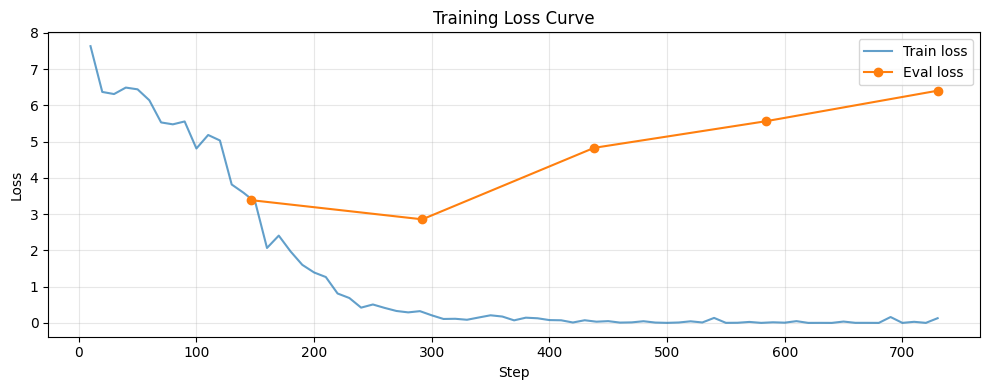

In [20]:
# Check training loss curve
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
train_steps = [x["step"] for x in log_history if "loss" in x]
train_loss = [x["loss"] for x in log_history if "loss" in x]
eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(train_steps, train_loss, label="Train loss", alpha=0.7)
if eval_loss:
    ax.plot(eval_steps, eval_loss, "o-", label="Eval loss", markersize=6)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Save & Download

In [21]:
# Save the finetuned model
final_path = f"{OUTPUT_DIR}/final"
model.save_pretrained(final_path)
print(f"Model saved to: {final_path}")

# Optional: push to HuggingFace Hub
# from huggingface_hub import notebook_login
# notebook_login()
# model.push_to_hub("your-username/jina-v5-nano-arabic-dict-retrieval")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./jina-v5-nano-finetuned/final


In [22]:
# Package and download model weights
import zipfile, os

zip_path = "jina_v5_nano_finetuned.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, fnames in os.walk(final_path):
        for fname in fnames:
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, final_path)
            z.write(fpath, arcname)
            print(f"  {arcname} ({os.path.getsize(fpath)/1e6:.1f} MB)")

total_mb = os.path.getsize(zip_path) / 1e6
print(f"\nZip: {zip_path} ({total_mb:.0f} MB)")

from google.colab import files
files.download(zip_path)

  modules.json (0.0 MB)
  configuration_eurobert.py (0.0 MB)
  model.safetensors (423.5 MB)
  config.json (0.0 MB)
  modeling_eurobert.py (0.0 MB)
  tokenizer.json (17.2 MB)
  sentence_bert_config.json (0.0 MB)
  tokenizer_config.json (0.0 MB)
  config_sentence_transformers.json (0.0 MB)
  README.md (0.1 MB)
  1_Pooling/config.json (0.0 MB)

Zip: jina_v5_nano_finetuned.zip (339 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. (Optional) Finetune v5-small with LoRA

The v5-small model (677M params, 1024-dim embeddings) is more powerful but too large
for full finetuning on a T4. Using LoRA, we freeze the base weights and only train
lightweight adapter matrices (~6.7M trainable params), reducing VRAM to ~4-8GB.

**Skip this section if v5-nano results are sufficient.**

In [ ]:
# Load v5-small pre-merged retrieval checkpoint
SMALL_MODEL_ID = "jinaai/jina-embeddings-v5-text-small-retrieval"

model_small = SentenceTransformer(
    SMALL_MODEL_ID,
    trust_remote_code=True,
    model_kwargs={"dtype": torch.bfloat16},
)
model_small.max_seq_length = 512

print(f"Model: {SMALL_MODEL_ID}")
print(f"Parameters: {sum(p.numel() for p in model_small.parameters()):,}")
print(f"Embedding dim: {model_small.get_sentence_embedding_dimension()}")

In [ ]:
# Add LoRA adapter — targets the Qwen3 attention projections
from peft import LoraConfig, TaskType

peft_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)

model_small.add_adapter(peft_config)

trainable = sum(p.numel() for p in model_small.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_small.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

In [ ]:
# Baseline eval for v5-small
evaluator_small = build_evaluator(eval_dataset, name="jina-v5-small-eval")

print("Running v5-small baseline evaluation...")
baseline_small = evaluator_small(model_small)

eval_name_small = "jina-v5-small-eval"
print("\nv5-small BASELINE:")
baseline_small_results = {}
for label, key in baseline_keys.items():
    full_key = f"{eval_name_small}_{key}"
    val = baseline_small.get(full_key, 0)
    baseline_small_results[label] = val
    print(f"  {label:12s} {val:.4f}")

In [ ]:
# Train v5-small with LoRA
loss_small = MatryoshkaLoss(
    model=model_small,
    loss=MultipleNegativesRankingLoss(model_small),
    matryoshka_dims=[1024, 768, 512, 256, 128, 64, 32],  # v5-small dims
    matryoshka_weights=[1.0] * 7,
)

args_small = SentenceTransformerTrainingArguments(
    output_dir="./jina-v5-small-finetuned",
    num_train_epochs=5,
    per_device_train_batch_size=16,  # smaller batch for LoRA + larger model
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    bf16=True,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    logging_steps=10,
)

trainer_small = SentenceTransformerTrainer(
    model=model_small,
    args=args_small,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=loss_small,
    evaluator=evaluator_small,
)

print("Training v5-small with LoRA...")
trainer_small.train()
print("\nTraining complete!")

In [ ]:
# Final comparison: v5-nano (full) vs v5-small (LoRA)
finetuned_small = evaluator_small(model_small)

print("\n" + "=" * 75)
print(f"{'Metric':12s}  {'nano base':>10s}  {'nano FT':>10s}  {'small base':>10s}  {'small FT':>10s}")
print("=" * 75)
for label, key in baseline_keys.items():
    nb = baseline_results[label]
    nf = finetuned_metrics.get(f"{eval_name}_{key}", 0)
    sb = baseline_small_results[label]
    sf = finetuned_small.get(f"{eval_name_small}_{key}", 0)
    print(f"  {label:12s}  {nb:10.4f}  {nf:10.4f}  {sb:10.4f}  {sf:10.4f}")
print("=" * 75)

# Save v5-small LoRA adapter
model_small.save_pretrained("./jina-v5-small-finetuned/final")
print("\nv5-small adapter saved.")